<a href="https://colab.research.google.com/github/mukedon/python_studies/blob/main/monte_carlo_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo Simulation

In [1]:
import numpy as np
import scipy as sp
import sympy as smp
import matplotlib.pyplot as plt

print('Libraries are imported.')

Libraries are imported.


## Introduction
Monte Carlo simulation is a computational algorithm that uses repeated random sampling to estimate the likelihood of various outcomes in uncertain events. It replaces fixed inputs with probability distributions to model possible results, helping decision-makers assess risks and uncertainties.

(Following video tutorial by [Mr. P Solver]( https://www.youtube.com/watch?v=U00Kseb6SB4) and [GitHub respository](https://github.com/lukepolson/youtube_channel/blob/main/Python%20Tutorial%20Series/montecarlo1.ipynb))

* Counting number of radioactive decays from some radioactive source in a time interval $\Delta t$. The random variable here is energy $E$ and follow a **Poisson** probability mass function (which discrete values in a sense as we are looking to derivative of a value):
$$
  f(x) = \frac{e^{-λ}λ^x}{x!}
$$

* Determining the energy of detected particles in a detector cell in the ATLAS calorimeter in a time interval $Δt$. The random variable here is energy $E$ (positive real number) and the corresponding probability density function is (which is a solution to an integral meaning that is continuous):
$$
  f(x) = F_1 e^{-\sqrt{x/E_1}} + F_2 e^{-\sqrt{x/E_2}}
$$

* Determining the distance a particle travels through matter before it completely decays. The random variable here is distance $X$ and a really simple probability density function model might be:
$$
  f(x) = \frac{x_0}{x_2} \qquad x \geq x_0
$$

Comparing first and second example; they appear as two sides of a coin, first checks discrete results while seconds issues continuous results.

For most cases this boils down into two steps

1. Generate Random Variables According to a Distribution
2. Use These Random Variables to Conduct Some Experiment

* Estimating a value for $π$.

In [2]:
from numpy.random import uniform

In [3]:
4 * np.sum(uniform(size=300000000)**2 + uniform(size=300000000)**2 < 1) / 300000000

3.1416642133333332

In [4]:
# Calculating error rate
ans = 4 * np.sum(uniform(size=300000000)**2 + uniform(size=300000000)**2 < 1) / 300000000
np.abs(ans - np.pi) / np.pi * 100

0.0006867086911670523

## 1 - Generate random variables according to Distribution

### 1.1 - Inverting the cumulative density function (CDF) analytically

The CDF describes the probability that a random variable takes a value less than or equal to a specific point. It is a non-decreasing function that ranges from 0 to 1, representing the accumulated probability up to that point.

**Calculating a CDF:**
Example:
$$
  f_z(z) =
  \begin{cases}
    γ(1+z^2) & -2 \leq z \leq 1 \\
    0 & \text{otherwise}
  \end{cases}
$$
1. figure out what $γ$ is:
$$
  \begin{align}
    1 &= \int_{-∞}^∞ f_z(z) dz = \int_{-∞}^∞ γ(1+z^2) dz \qquad \text{sum of probs. for the PDF: $f_z(z)$} \\
    &= \int_{-2}^1 γ(1+z^2) dz \qquad \text{outside of $[-2, 1]$ $f_z(z)$ is zero} \\
    &= γ \int_{-2}^1 (1+z^2) dz = \gamma \big[ z + \frac{z^3}{3} \big]_{-2}^1 = γ \big( \frac{4}{3} + \frac{14}{3} \big) \\
    &= γ(6) = 6γ ⇒ γ = \frac{1}{6}
  \end{align}
$$
Plot of the PDF:

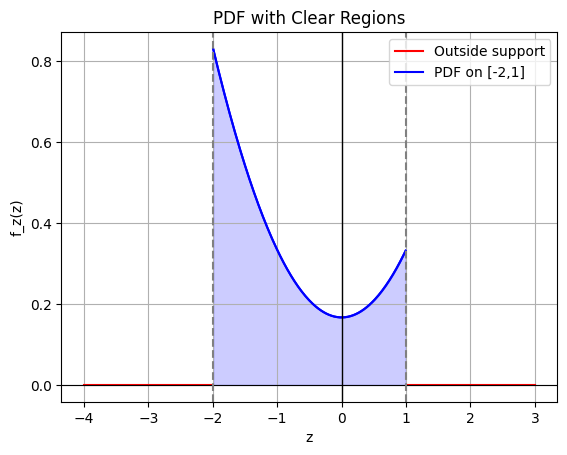

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# PDF
def f(z):
    return (1/6) * (1 + z**2)

z = np.linspace(-4, 3, 500)

# Regions
z_left = z[z < -2]
z_mid = z[(z >= -2) & (z <= 1)]
z_right = z[z > 1]

plt.figure()

# Plot regions separately
plt.plot(z_left, np.zeros_like(z_left), 'r', label='Outside support')
plt.plot(z_mid, f(z_mid), 'b', label='PDF on [-2,1]')
plt.plot(z_right, np.zeros_like(z_right), 'r')

# Fill the valid region
plt.plot(z_mid, f(z_mid), color='blue')
plt.fill_between(z_mid, f(z_mid), color='blue', alpha=0.2)

# Axes in neutral colour
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=1)

# Vertical boundaries
plt.axvline(-2, linestyle='--', color='grey')
plt.axvline(1, linestyle='--', color='grey')

plt.xlabel('z')
plt.ylabel('f_z(z)')
plt.title('PDF with Clear Regions')
plt.legend()
plt.grid()

plt.show()

2. calculate CDF out PDF:
$$
  F_z(z) = \int_{-∞}^z f_z(y)dy \qquad \text{for values less than z $(-∞, z]$}
$$
**case:** $-2 \leq z \leq 1$;
$$
  \begin{align}
    \int_{-2}^z \frac{1}{6} (1 + y^2) dy &= \frac{1}{6} \bigg[ y + \frac{y^3}{3} \bigg]_{-2}^z \\
    &= \frac{1}{6} \bigg[ (z + \frac{z^3}{3}) + \frac{14}{3}\bigg]
  \end{align}
$$
$$
  F_z(z) =
  \begin{cases}
    0 & z \leq -2 \\
    \frac{1}{6} \bigg[ (z + \frac{z^3}{3}) + \frac{14}{3}\bigg] & -2 < z < 1 \\
    1 & z > 1
  \end{cases}
$$
Here, $F_z(z) = 1$ at $z > 1$ because CDF is accumulating the probabilities between $(-2, 1)$ once it reaches the point 1, total area under the curve is $1$. Therefore, when it continues beyond $1$, the cumulative probability is still $1$ since probability is between $[0, 1]$. This can also be seen in plot of CDF down below.

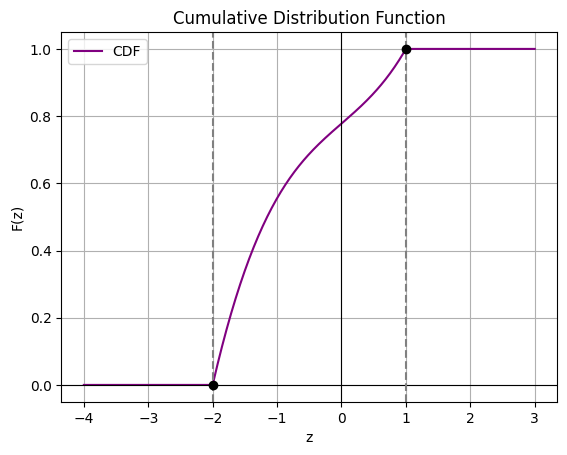

In [6]:
# CDF
def F(z):
    z = np.array(z)
    result = np.zeros_like(z, dtype=float)

    # Middle region
    mask_mid = (z >= -2) & (z <= 1)
    result[mask_mid] = (1/6) * (z[mask_mid] + z[mask_mid]**3 / 3 + 14/3)

    # Right region
    result[z > 1] = 1

    return result

z = np.linspace(-4, 3, 500)

plt.figure()

# Plot CDF
plt.plot(z, F(z), color='purple', label='CDF')

# Mark important points
plt.scatter([-2, 1], [0, 1], color='black', zorder=3)

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Boundaries
plt.axvline(-2, linestyle='--', color='grey')
plt.axvline(1, linestyle='--', color='grey')

plt.xlabel('z')
plt.ylabel('F(z)')
plt.title('Cumulative Distribution Function')
plt.legend()
plt.grid()

plt.show()

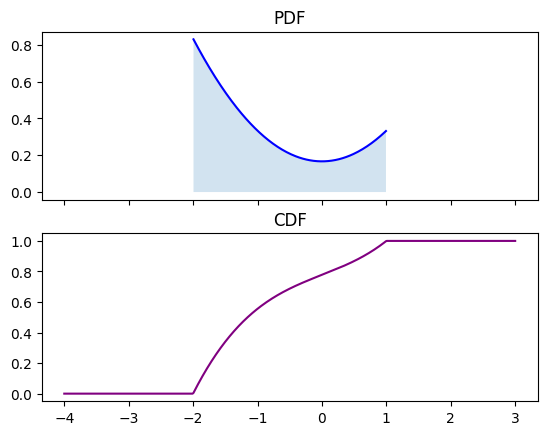

In [7]:
fig, axs = plt.subplots(2, 1, sharex=True)

# PDF
axs[0].plot(z_mid, f(z_mid), color='blue')
axs[0].fill_between(z_mid, f(z_mid), alpha=0.2)
axs[0].set_title("PDF")

# CDF
axs[1].plot(z, F(z), color='purple')
axs[1].set_title("CDF")

plt.show()

**Theorem:** If a random variable $X$ has a CDF of $F(x)$ then the variable $F^{-1}(U)$, where $U$ is a random uniform variable between 0 and 1, also has CDF $F(x)$:
$$
  X \sim F(x) ⟹ F^{-1}(U) ∼ F(x)
$$

**Example:** The exponential distribution is:
$$
  f(x) = λe^{-λx} ⟹ F(x) = 1 - e^{-λx}
$$

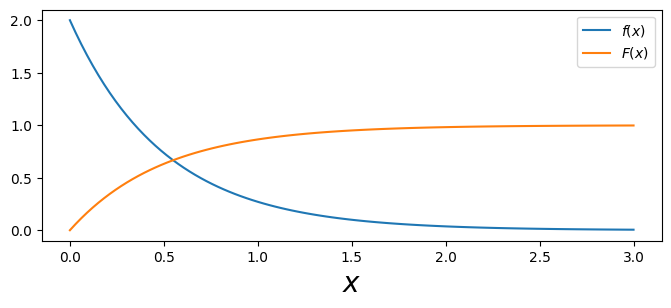

In [8]:
x = np.linspace(0,3,100)
f = 2*np.exp(-2*x)
F = 1 - np.exp(-2*x)

plt.figure(figsize=(8,3))
plt.plot(x, f, label=r'$f(x)$')
plt.plot(x, F, label=r'$F(x)$')
plt.legend()
plt.xlabel('$x$', fontsize=20)
plt.legend()
plt.show()

Using $F[F^{-1}(x)] = x$, presents:
$$
  1 - e^{-λF^{-1}(x)} = x = ⇒ \boxed{F^{-1}(x) = - \frac{ln(1 - x}{λ}}
$$

So if we evaluate a bunch of random uniform variables $U$ and evaluate $F^{-1}(U)$, they should be distributed according to $f(x)$ above.

In [9]:
Us = np.random.rand(10000)

<function matplotlib.pyplot.show(close=None, block=None)>

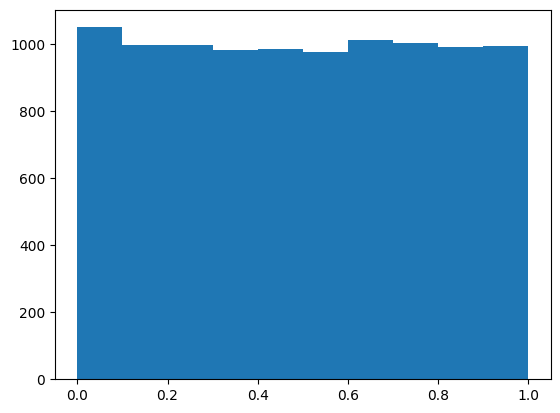

In [10]:
plt.hist(Us)
plt.show

In [11]:
F_inv_Us = -np.log(1 - Us)/2

Let's plot these and see if they really are distributed according to $f(x)$

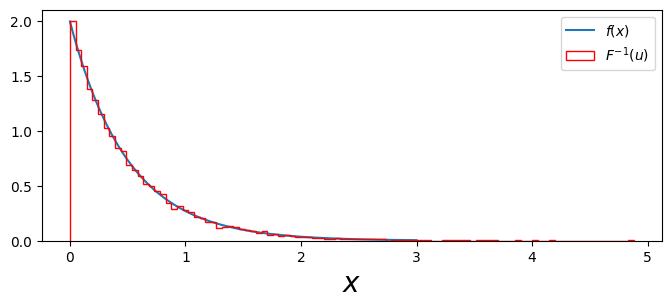

In [12]:
plt.figure(figsize=(8,3))
plt.plot(x, f, label=r'$f(x)$')
plt.hist(F_inv_Us, histtype='step', color='red', density='norm', bins=100, label='$F^{-1}(u)$')
plt.legend()
plt.xlabel('$x$', fontsize=20)
plt.legend()
plt.show()

### 1.2 - Using a search sort algorithm
Sometimes $F(x)$ isn't invertible analytically. But;
* $F(x)$ is always increasing with $x$: check plot of CDF again.

So it is neceassarily invertible (there just might not be a formula for it).
$$
  f(x) = F_1 e^{-\sqrt{x/E_1}} + F_2 e^{-\sqrt{x/E_2}}
$$

In [13]:
x, y, F1, F2, E1, E2 = smp.symbols('x y F_1 F_2 E_1 E_2', real=True, positive=True)
fs = F1*smp.exp(-smp.sqrt(x/E1)) + F2*smp.exp(-smp.sqrt(x/E2))
fs

F_1*exp(-sqrt(x)/sqrt(E_1)) + F_2*exp(-sqrt(x)/sqrt(E_2))

In [14]:
Fs = smp.integrate(fs, (x,0,y)).doit()
Fs

2*E_1*F_1 + 2*E_2*F_2 + F_1*(-2*sqrt(E_1)*sqrt(y)*exp(-sqrt(y)/sqrt(E_1)) - 2*E_1*exp(-sqrt(y)/sqrt(E_1))) + F_2*(-2*sqrt(E_2)*sqrt(y)*exp(-sqrt(y)/sqrt(E_2)) - 2*E_2*exp(-sqrt(y)/sqrt(E_2)))

In [15]:
Fn = smp.lambdify((y, E1, E2, F1, F2), Fs)
fn = smp.lambdify((x, E1, E2, F1, F2), fs)

Get parameters and actual numerical values

In [16]:
E1 = E2 = 0.2
F1 = 1.3
F2 = 1.4
x = np.linspace(0,5,1000)
f = fn(x, E1, E2, F1, F2)
F = Fn(x, E1, E2, F1, F2)

Plot

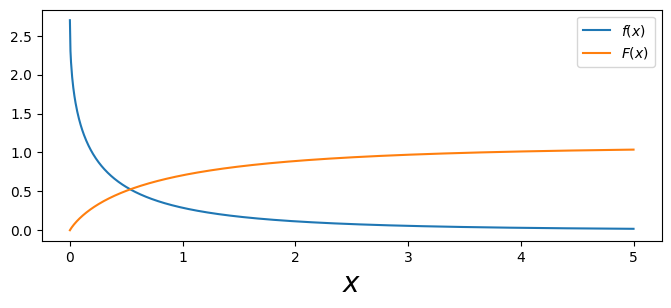

In [17]:
plt.figure(figsize=(8,3))
plt.plot(x, f, label=r'$f(x)$')
plt.plot(x,F, label=r'$F(x)$')
plt.legend()
plt.xlabel('$x$', fontsize=20)
plt.legend()
plt.show()

Clearly $F(x)$ is always increasing but inverting that formula would be hard. How can we approximate $F^{-1}(x)$ given the information we have?

Index based search and sort algoritm can help by directly aligning uniform variables $U$ to function that we are dealing with.

In [18]:
F_inv_Us = x[np.searchsorted(F[:-1], Us)]

Plot

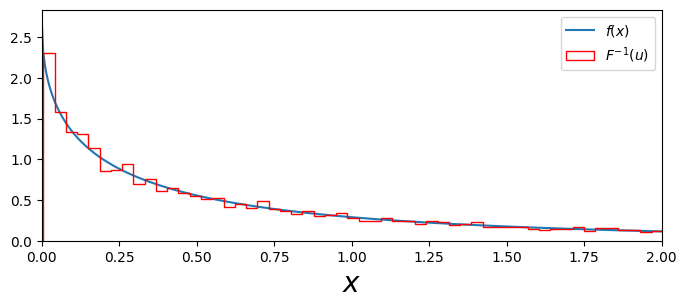

In [19]:
plt.figure(figsize=(8,3))
plt.plot(x, f, label=r'$f(x)$')
plt.hist(F_inv_Us, histtype='step', color='red', density='norm', bins=100, label='$F^{-1}(u)$')
plt.legend()
plt.xlabel('$x$', fontsize=20)
plt.legend()
plt.xlim(0,2)
plt.show()

### 1.3 - Built in Variables


In [20]:
r = np.random.rayleigh(size=1000)

Plot this

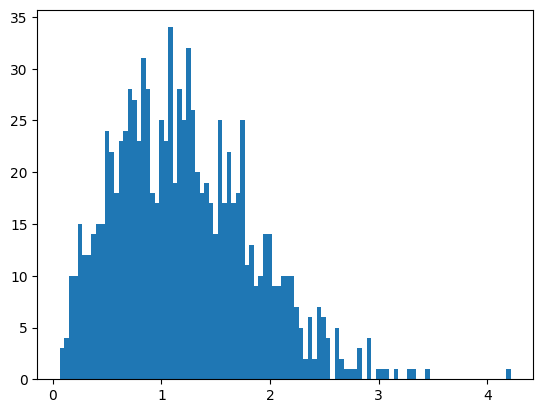

In [21]:
plt.hist(r, bins=100)
plt.show()

There are many random variable generators in numpy:

In [22]:
np.random?

Type:        module
String form: <module 'numpy.random' from 'c:\\projects\\qiskit_projects\\.venv\\Lib\\site-packages\\numpy\\random\\__init__.py'>
File:        c:\projects\qiskit_projects\.venv\lib\site-packages\numpy\random\__init__.py
Docstring:  
Random Number Generation

Use ``default_rng()`` to create a `Generator` and call its methods.

=============== =========================================================
Generator
--------------- ---------------------------------------------------------
Generator       Class implementing all of the random number distributions
default_rng     Default constructor for ``Generator``
=============== =========================================================

============================================= ===
BitGenerator Streams that work with Generator
--------------------------------------------- ---
MT19937
PCG64
PCG64DXSM
Philox
SFC64
============================================= ===

============================================= ===
Getting 

In [23]:
r_gamma = np.random.gamma(shape=2, scale=2, size=1000)

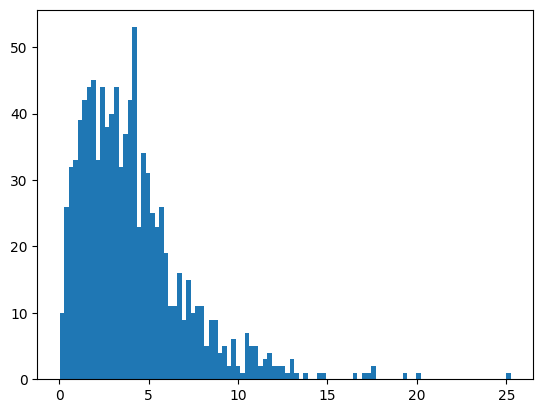

In [24]:
plt.hist(r_gamma, bins=100)
plt.show()

## 2 - Use these random variables to conduct an experiment

* The amount of particles that enter a detector in 10s is a random variable $X$ with distribution
$$
  f(x) = \frac{e^{-\lambda}λ^x}{x!}
$$
* The energy deposited by each particle is a random variable $E$ with distribution
$$
  g(x) = F_1 e^{-\sqrt{x/E_1}} + F_2 e^{-\sqrt{x/E_2}}
$$
The paramaters are:
* λ = 4
* $F_1 = 1.3 GeV^{-1}$
* $F_2 = 1.4 GeV^{-1}$
* $E_1 = 0.1 GeV$
* $E_2 = 0.2 GeV$

Simulate the energy in the detector over $100000$ experiments of $10$ seconds each. Plot the distribution.

In [25]:
N = 100000

# Part 1
X = np.random.poisson(lam=4, size=N)

# Part 2
x = np.linspace(0,5,1000)
F = Fn(x, E1, E2, F1, F2)
Us = np.random.rand(X.sum())
E = x[np.searchsorted(F[:-1], Us)]

Get a net sum of how many particles were detected total after $n$ experiments:

In [26]:
idx = np.insert(X.cumsum(), 0, 0)[:-1]
idx[0:10]

array([ 0,  0,  4,  6, 10, 12, 14, 15, 19, 26])

Use these values to sum energies for each experiment.

In [27]:
E[0:10]

array([0.10510511, 0.21521522, 0.07007007, 0.31031031, 0.04504505,
       0.07507508, 0.08008008, 1.62162162, 0.13513514, 0.05505506])

In [28]:
E_10s = np.add.reduceat(E, idx)

In [29]:
E_10s

array([0.10510511, 0.7007007 , 0.12012012, ..., 5.17017017, 0.25525526,
       5.99099099])

Plot

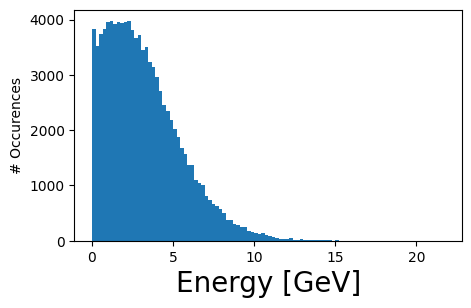

In [30]:
plt.figure(figsize=(5,3))
plt.hist(E_10s, bins=100)
plt.xlabel('Energy [GeV]', fontsize=20)
plt.ylabel('# Occurences')
plt.show()

This distribution is very interesting, and probably doesn't have a name, but it helps us with our experimental planning

In [31]:
np.sum(E_10s>7.5)/len(E_10s)

0.05211

So 5% of the time we expect more than 7.5GeV of energy to be deposited in the detector within 10s. This mght be useful when planning for resources, such as requirements for detecting this much energy!

## 3 - Quick overview
First assume we just gathering random numbers from a generator from `numpy`.

In [32]:
np.random.seed(42)

#### 3.1 - Monte Carlo workflow
1. Define a probabilistic model
2. Generate $N$ random samples
3. Compute functionals of interest
4. Aggregate results (mean, variance, confidence intervals)

By the law of larger numbers:
$$
  \lim_{N \to ∞} \frac{1}{N} \sum_{i=1}^N X_i = \mathbb{E}[X]
$$

### 3.2 - Writing a simulation:
Estimating $π$ by random sampling inside a unit square:

In [33]:
def estimate_pi(n_samples: int=100000) -> float:
  # 1. Sample points in [0,1] x [0,1]
  x = np.random.rand(n_samples)
  y = np.random.rand(n_samples)

  # 2. Count points inside the quarter circle x^2 + y^2 ≤ 1
  inside = (x**2 + y**2) <= 1.0

  # 3. Ratio approximates π/4
  pi_estimate = 4 * np.mean(inside)
  return pi_estimate

if __name__ == "__main__":
  np.random.seed(0)
  print(f"π ≈ {estimate_pi(100000):.5f}")

π ≈ 3.13364


In [34]:
import pandas as pd

results = pd.DataFrame({
    'trial': np.arange(1, 101),
    'estimate': [estimate_pi(100_000) for _ in range(100)]
})
print(results.describe())

            trial    estimate
count  100.000000  100.000000
mean    50.500000    3.141615
std     29.011492    0.005745
min      1.000000    3.123240
25%     25.750000    3.137710
50%     50.500000    3.142060
75%     75.250000    3.145300
max    100.000000    3.154640


In [35]:
from scipy.stats import norm

# Example: simulate returns with Normal(μ=0.01, σ=0.05)
samples = norm.rvs(loc=0.01, scale=0.05, size=1_000_000)

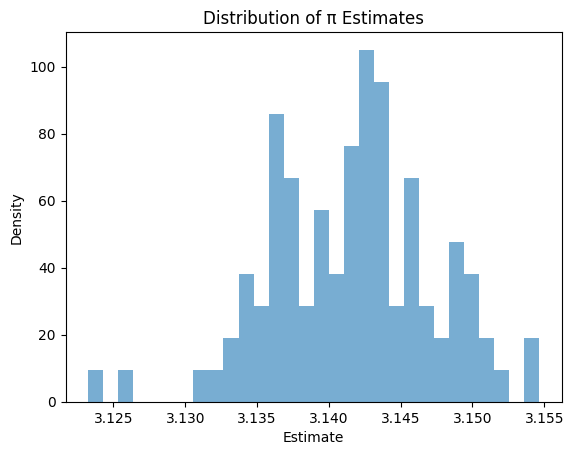

In [36]:
plt.hist(results['estimate'], bins=30, density=True, alpha=0.6)
plt.title("Distribution of π Estimates")
plt.xlabel("Estimate")
plt.ylabel("Density")
plt.show()

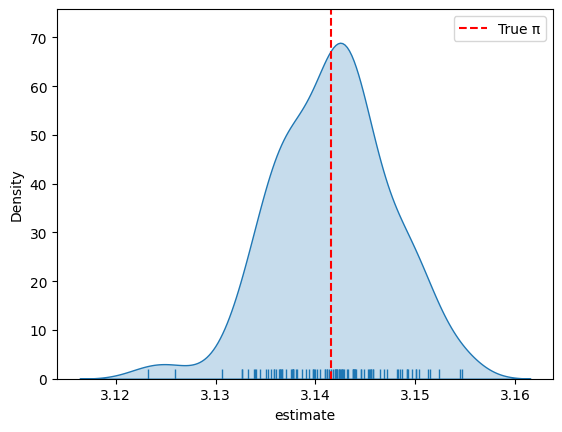

In [37]:
import seaborn as sns

sns.kdeplot(results['estimate'], fill=True)
sns.rugplot(results['estimate'])
plt.axvline(np.pi, color='red', linestyle='--', label='True π')
plt.legend()

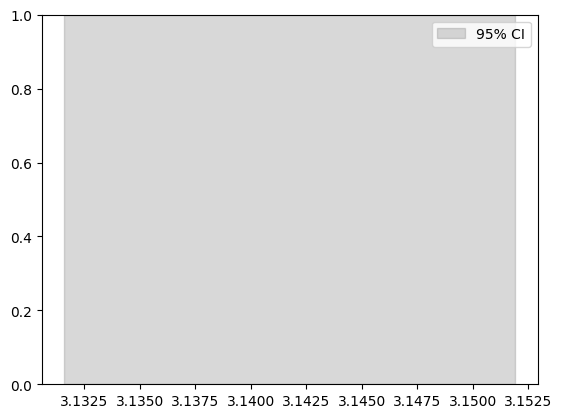

In [39]:
ci_low, ci_high = np.percentile(results['estimate'], [2.5, 97.5])
plt.axvspan(ci_low, ci_high, color='gray', alpha=0.3, label='95% CI')
plt.legend()

In [40]:
import random


def estimate_pi(num_points):
    points_inside_circle = 0
    for _ in range(num_points):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        distance = x ** 2 + y ** 2
        if distance <= 1:
            points_inside_circle += 1
    pi_estimate = 4 * (points_inside_circle / num_points)
    return pi_estimate


num_points = 1000000
print(f"Estimated value of pi with {num_points} points: {estimate_pi(num_points)}")

Estimated value of pi with 1000000 points: 3.143612


Estimated value of pi with 1000000 points using numpy: 3.140584


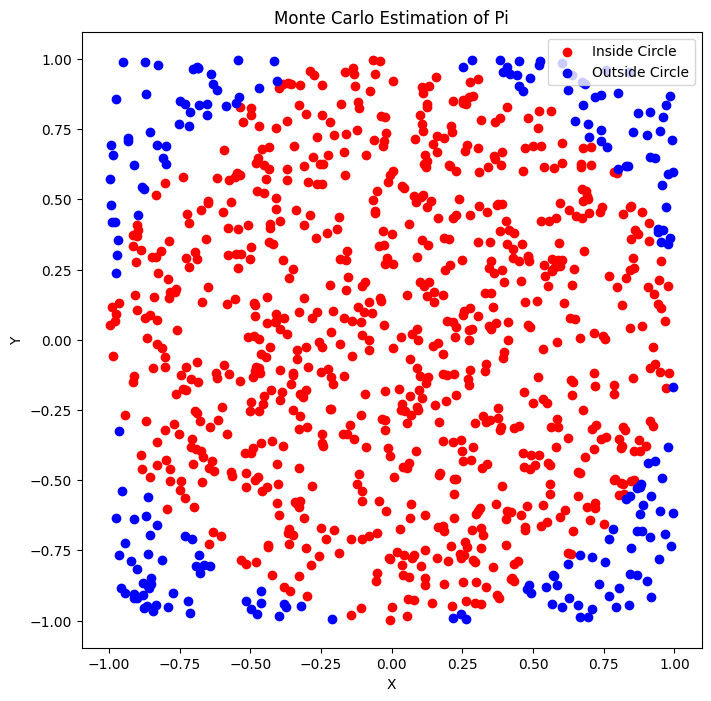

In [42]:
import numpy as np
import matplotlib.pyplot as plt


def estimate_pi_numpy(num_points):
    points = np.random.uniform(-1, 1, size=(num_points, 2))
    distances = np.sqrt(points[:, 0] ** 2 + points[:, 1] ** 2)
    points_inside_circle = np.sum(distances <= 1)
    pi_estimate = 4 * (points_inside_circle / num_points)
    return pi_estimate


num_points = 1000000
pi_estimate = estimate_pi_numpy(num_points)
print(f"Estimated value of pi with {num_points} points using numpy: {pi_estimate}")

# Visualization
points = np.random.uniform(-1, 1, size=(1000, 2))
distances = np.sqrt(points[:, 0] ** 2 + points[:, 1] ** 2)
inside_circle = distances <= 1

plt.figure(figsize=(8, 8))
plt.scatter(points[inside_circle, 0], points[inside_circle, 1], color='red', label='Inside Circle')
plt.scatter(points[~inside_circle, 0], points[~inside_circle, 1], color='blue', label='Outside Circle')
plt.title('Monte Carlo Estimation of Pi')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()